# Bước 1: Nhập và tiền xử lý ảnh

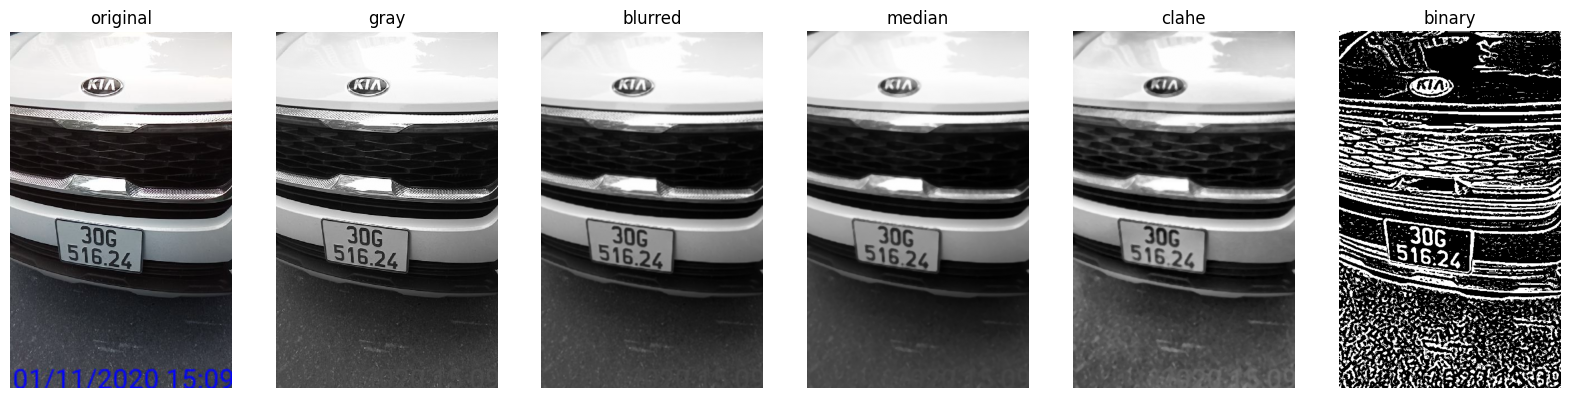

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Hàm để hiển thị hình ảnh
def display_image(images, titles):
    plt.figure(figsize=(20,10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
def load_and_preprocess(image_path):
    # 1. Tải ảnh
    original_image = cv2.imread(image_path)
    if original_image is None:
        print("Lỗi: Không thể tải ảnh.")
    else:
        # 2. Tiền xử lý 
        # Chuyển đổi sang ảnh xám
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        # Gaussian Blur để giảm nhiễu
        blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        # Median Filter để giảm nhiễu nhiều hơn
        median_image = cv2.medianBlur(blurred_image, 5)
        # CLAHE để tăng cường độ tương phản
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_image = clahe.apply(median_image)
        # Binarization để phát hiện contours
        binary_image = cv2.adaptiveThreshold(
            clahe_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 11, 2
        )
        # 3. Trả về một dictionary để dễ dàng truy cập các bước
        return {
            "original": original_image,
            "gray": gray_image,
            "blurred": blurred_image,
            "median": median_image,
            "clahe": clahe_image,
            "binary": binary_image
        }
# Test 
image_path = r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg'
process_images = load_and_preprocess(image_path)
if process_images:
    display_image(list(process_images.values()), list(process_images.keys()))

# Bước 2: Phát hiện biển số xe bằng Canny Edge và Morphology

Tạo hàm `detect_license_plate()`:
1. Tìm cạnh (Canny)
2. Đóng các khoảng trống (Phép đóng)
3. Loại bỏ nhiễu nhỏ (Phép mở)
4. Tìm đường viền (contours)
5. Lọc ra các đường viền phù hợp là biển số xe
6. In và Test

✓ Phát hiện 1 vùng biển số
  Plate 1: vị trí=(73, 337), kích thước=(168x102), tỷ lệ=1.65


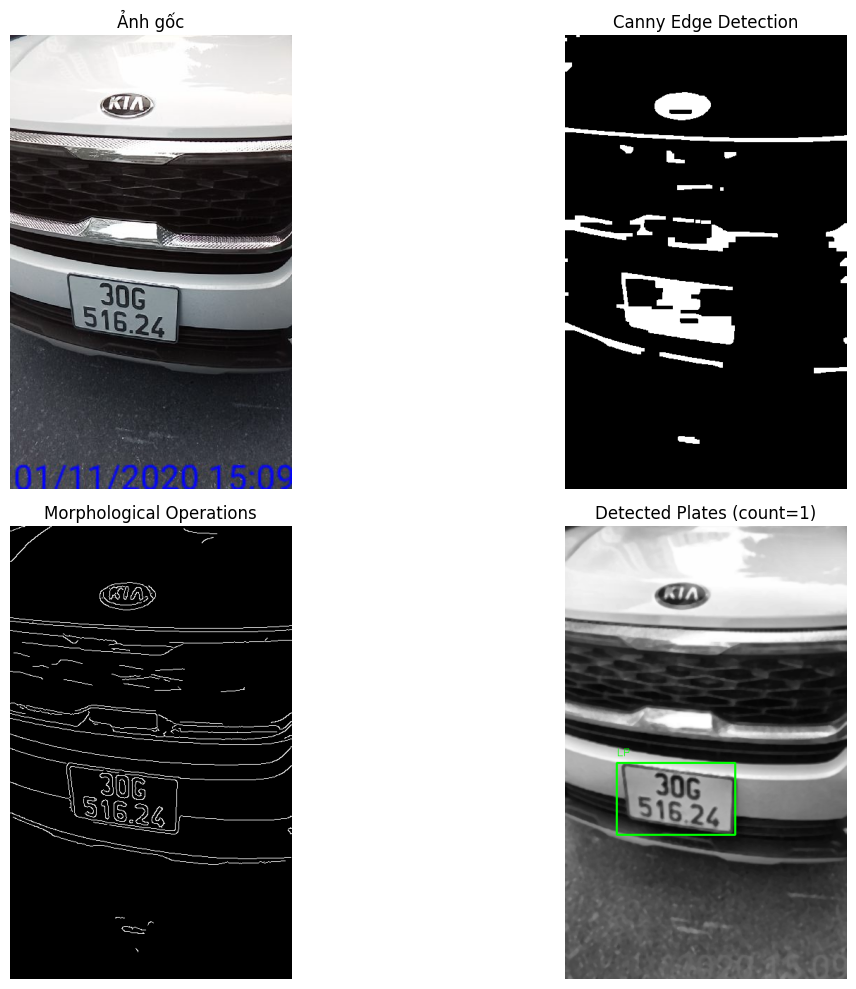

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_license_plate(image_preprocessed, canny_threshold1 = 100, canny_threshold2 = 200, 
                         min_area = 5000, aspect_ratio_range = (1.0, 2.5)):
    # 1. Phát hiện cạnh sử dụng Canny
    edges = cv2.Canny(image_preprocessed, canny_threshold1, canny_threshold2)
    
    # 2. Sử dụng Morphology để đóng các khoảng trống (phép đóng để nối các cạnh thành vùng liên tục)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    
    # 3. Phép mở để loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc contours dựa trên diện tích và tỷ lệ khung hình
    plates = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # kiểm tra điều kiện diện tích và tỷ lệ khung hình
        if (area >= min_area and 
            aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            plates.append((x, y, w, h))
    return plates, morph, edges

# Test
detected_plates, edges_img, morph_img = detect_license_plate(process_images['clahe'])

print(f"✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ảnh gốc
axes[0, 0].imshow(process_images['original'], cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Ảnh Canny edges
axes[0, 1].imshow(edges_img, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection')
axes[0, 1].axis('off')

# Ảnh sau morphology
axes[1, 0].imshow(morph_img, cmap='gray')
axes[1, 0].set_title('Morphological Operations')
axes[1, 0].axis('off')

# Ảnh gốc với bounding boxes
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in detected_plates:
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Tinh chỉnh và nâng cấp hàm `detect_license_plate` với **Adaptive Threshold** & **Geometric Filters**
---
1. Tính tự động ngưỡng Canny bằng **Median-based adaptive**
2. Giữ nguyên các bước xử lý
3. Sau khi tìm contours sẽ áp dụng Geometric Filtering:
    - Diện tích 
    - Tỷ lệ khung hình 
    - Độ "đặc" 
    - Khoảng cách từ cạnh ảnh
4. Tiếp tục cải tiến Adaptive Area & Kernel Size
5. In và Test

In [54]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def auto_canny (image, sigma = 0.33):
    """
    Tính Canny thresholds tự động dựa trên median pixel value
    Phương pháp: Median-based Adaptive Thresholding (sử dụng Heuristic)
    Ý tưởng: Giả định các cạnh quan trọng trong ảnh sẽ có gradients cỡ median
    """
    # Tính median pixel value
    v = np.median(image)
    
    # Áp dụng sigma để tính lower và upper thresholds
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    
    return lower, upper
def detect_license_plate_v2(image_preprocessed,
                            sigma = 0.33,
                            min_area = 5000,
                            max_area = 50000,
                            aspect_ratio_range=(0.8, 3.5),
                            min_solidity = 0.5,
                            debug=False):
    """
    Args:
        image_preprocessed: Ảnh đã qua tiền xử lý (CLAHE)
        sigma: Hệ số Heuristic để tính Canny
        min_area, max_area:  Khoảng diện tích contour hợp lệ
        aspect_ratio_range: Khoảng W/H (nới lỏng để có nhiều trường hợp).
        min_solidity: Mức độ "đặc" của contour (0-1, cao = hình dạng rõ ràng)
        debug: In thông tin chi tiết
    Returns:
        plates: Danh sách bounding boxes của biển số được phát hiện
        debug_info: Dictionary chứa intermediate images & stats
    """
    # 1. Tính ngưỡng Canny tự động
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma = sigma)
    if debug:
        print(f"✓ Auto Canny thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # 2. Phát hiện cạnh 
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # 3. Xử lý hình thái (Morphology)
    # Phép đóng: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Phép mở: loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)   
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc Geometric 
    plates = []
    rejected_stats = {"area":0, "aspect_ratio":0, "solidity":0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # Lọc 1: Diện tích
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # Lọc 2: Tỷ lệ khung hình (W/H)
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # Lọc 3: Độ "đặc" (solidity)
        # Solidity = Area / Convex Hull Area
        # Giá trị cao = hình dạng đặc (ít có lỗ), thấp = rỗng hoặc nhiễu
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # Lọc 4: Khoảng cách từ cạnh ảnh (Tránh detect phần xe)
        margin = 10
        if x <= margin or y <= margin or (x + w) >= (image_preprocessed.shape[1] - margin) or (y + h) >= (image_preprocessed.shape[0] - margin):
            continue
        
        # Nếu vượt qua tất cả các bộ lọc, thêm vào danh sách plates
        plates.append((x, y, w, h))
        
        if debug:
            print(f"✓ Detected plate: pos=({x}, {y}), size=({w}x{h}), area={area}, aspect_ratio={aspect_ratio:.2f}, solidity={solidity:.2f}")
    # DEBUG INFO
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    return plates, debug_info
detect_license_plate_v2(process_images['clahe'], debug=True)

✓ Auto Canny thresholds: lower=60, upper=119
✓ Detected plate: pos=(55, 337), size=(190x102), area=12993.5, aspect_ratio=1.86, solidity=0.92

📈 Tổng kết:
  • Tìm được 67 contours
  • Bị từ chối (diện tích): 65
  • Bị từ chối (tỷ lệ): 1
  • Bị từ chối (solidity): 0
  • ✅ Phát hiện 1 biển số hợp lệ


([(55, 337, 190, 102)],
 {'edges': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(644, 400), dtype=uint8),
  'morph': array([[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], shape=(644, 400), dtype=uint8),
  'contours': 67,
  'canny_lower': 60,
  'canny_upper': 119,
  'rejected': {'area': 65, 'aspect_ratio': 1, 'solidity': 0},
  'plates_count': 1})

📐 Image dimensions: 400x644, area=257600
   Adaptive area range: 5152-38640 (2.0%-15.0%)
📊 Auto Canny Thresholds: lower=60, upper=119
🔧 Adaptive kernel: close_kernel=(41, 13)

📈 Tổng kết:
  • Tìm được 18 contours
  • Bị từ chối (diện tích): 17
  • Bị từ chối (tỷ lệ): 0
  • Bị từ chối (solidity): 0
  • ✅ Phát hiện 0 biển số hợp lệ

✓ Phát hiện 0 vùng biển số


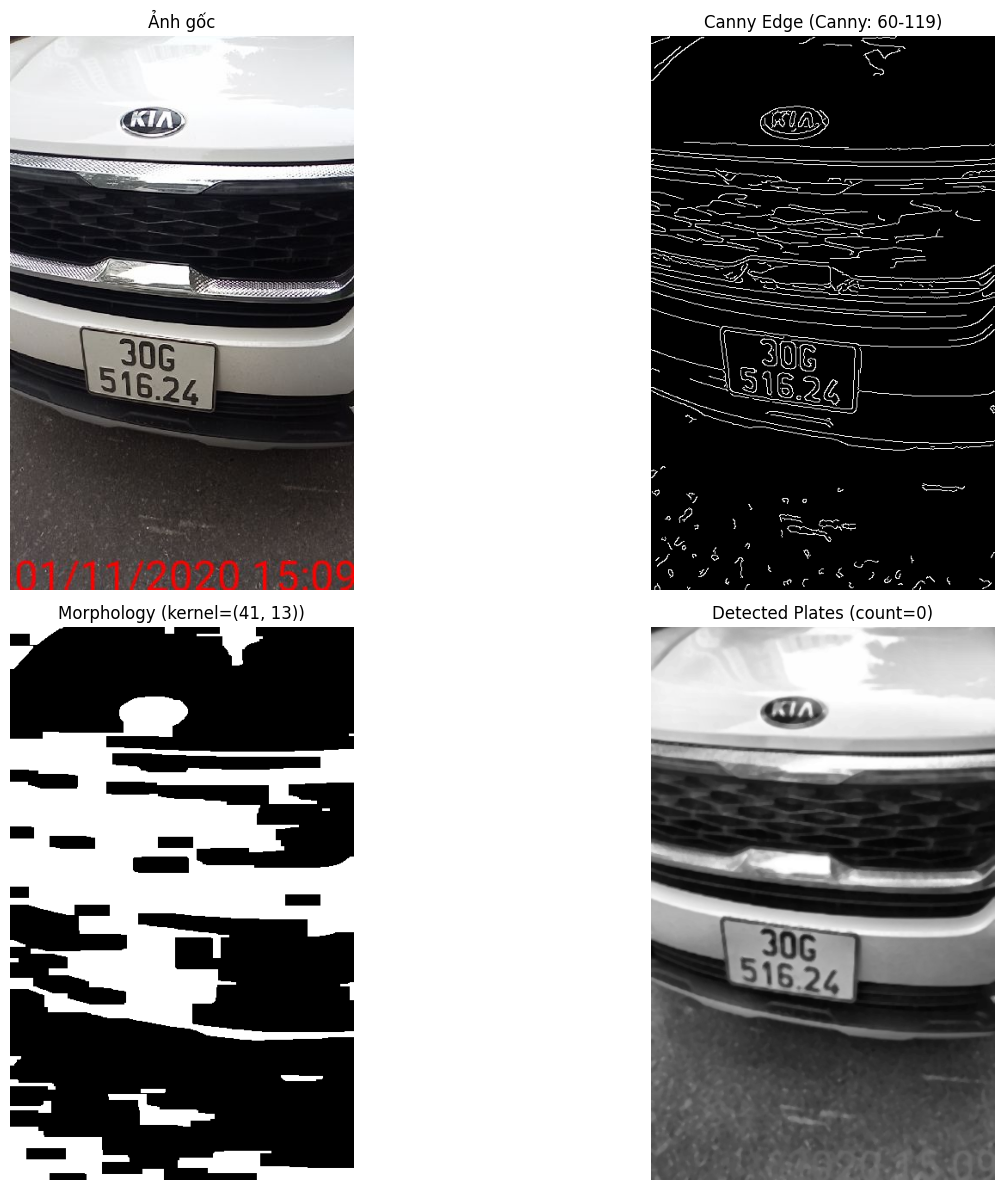

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """
    Tính tự động Canny thresholds dựa trên median pixel value.
    """
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3(image_preprocessed,
                             sigma=0.33,
                             area_ratio_range=(0.02, 0.15),  # 2%-15% của diện tích ảnh
                             aspect_ratio_range=(0.8, 3.5),
                             min_solidity=0.5,
                             kernel_width_ratio=0.1,  # 10% chiều rộng ảnh
                             kernel_height_ratio=0.02, # 2% chiều cao ảnh
                             debug=False):
    """
    Phát hiện biển số với Adaptive Parameters (tỷ lệ % diện tích ảnh).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: Tuple(min%, max%) - % diện tích ảnh (tỷ lệ 0-1)
                         VD: (0.02, 0.15) = 2%-15% diện tích ảnh
        aspect_ratio_range: Khoảng W/H của biển số
        min_solidity: Mức độ "đặc" của contour (0-1)
        kernel_width_ratio: % chiều rộng ảnh để tính kernel width (VD: 0.1 = 10%)
        kernel_height_ratio: % chiều cao ảnh để tính kernel height (VD: 0.02 = 2%)
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)] - bounding boxes
        debug_info: Dictionary chứa intermediate images & statistics
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    # ========== 1. ADAPTIVE AREA THRESHOLDS (dựa trên % diện tích ảnh) ==========
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image dimensions: {img_width}x{img_height}, area={img_area}")
        print(f"   Adaptive area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    # ========== 2. AUTO CANNY THRESHOLDS ==========
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Auto Canny Thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # ========== 3. CANNY EDGE DETECTION ==========
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # ========== 4. ADAPTIVE MORPHOLOGICAL OPERATIONS ==========
    # Tính kích thước kernel dựa trên kích thước ảnh
    kernel_width = max(5, int(img_width * kernel_width_ratio))
    kernel_height = max(3, int(img_height * kernel_height_ratio))
    
    # Đảm bảo kernel có kích thước lẻ (required by OpenCV)
    if kernel_width % 2 == 0:
        kernel_width += 1
    if kernel_height % 2 == 0:
        kernel_height += 1
    
    if debug:
        print(f"🔧 Adaptive kernel: close_kernel=({kernel_width}, {kernel_height})")
    
    # Close kernel: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Open kernel: loại bỏ nhiễu nhỏ (nhỏ hơn close kernel)
    kernel_open_w = max(3, kernel_width // 5)
    kernel_open_h = max(3, kernel_height // 5)
    if kernel_open_w % 2 == 0:
        kernel_open_w += 1
    if kernel_open_h % 2 == 0:
        kernel_open_h += 1
    
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_open_w, kernel_open_h))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # ========== 5. FIND CONTOURS ==========
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ========== 6. GEOMETRIC FILTERING ==========
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # **Filter 1: Diện tích (adaptive dựa % ảnh)**
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # **Filter 2: Tỷ lệ khung hình (W/H)**
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # **Filter 3: Solidity (độ "đặc" của contour)**
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # **Filter 4: Khoảng cách từ cạnh ảnh**
        margin = max(5, int(img_width * 0.05))  # 5% chiều rộng hoặc 5px (cái nào lớn hơn)
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            continue
        
        # ✅ Passed all filters
        plates.append((x, y, w, h))
        
        if debug:
            print(f"  ✓ Plate found: Area={area:.0f}, AR={aspect_ratio:.2f}, Solidity={solidity:.2f}")
    
    # ========== DEBUG INFO ==========
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": contours,
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": (kernel_width, kernel_height),
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    
    return plates, debug_info

# ========== TEST ==========
detected_plates, debug_info = detect_license_plate_v3(
    process_images['clahe'],
    sigma=0.33,
    area_ratio_range=(0.02, 0.15),  # 2%-15% diện tích ảnh
    kernel_width_ratio=0.1,          # 10% chiều rộng
    kernel_height_ratio=0.02,        # 2% chiều cao
    min_solidity=0.5,
    debug=True
)

print(f"\n✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# ========== VISUALIZE ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny edges
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny Edge (Canny: {debug_info['canny_lower']}-{debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology result
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result with detected plates
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

📐 Image dimensions: 400x644, area=257600
   Adaptive area range: 5152-51520 (2.0%-20.0%)
📊 Auto Canny Thresholds: lower=60, upper=119
🔧 Adaptive kernel: close_kernel=(33, 9)

📈 Tổng kết:
  • Tìm được 35 contours
  • Bị từ chối (diện tích): 33
  • Bị từ chối (tỷ lệ): 0
  • Bị từ chối (solidity): 1
  • Bị từ chối (margin): 1
  • ✅ Phát hiện 0 biển số hợp lệ

✓ Phát hiện 0 vùng biển số


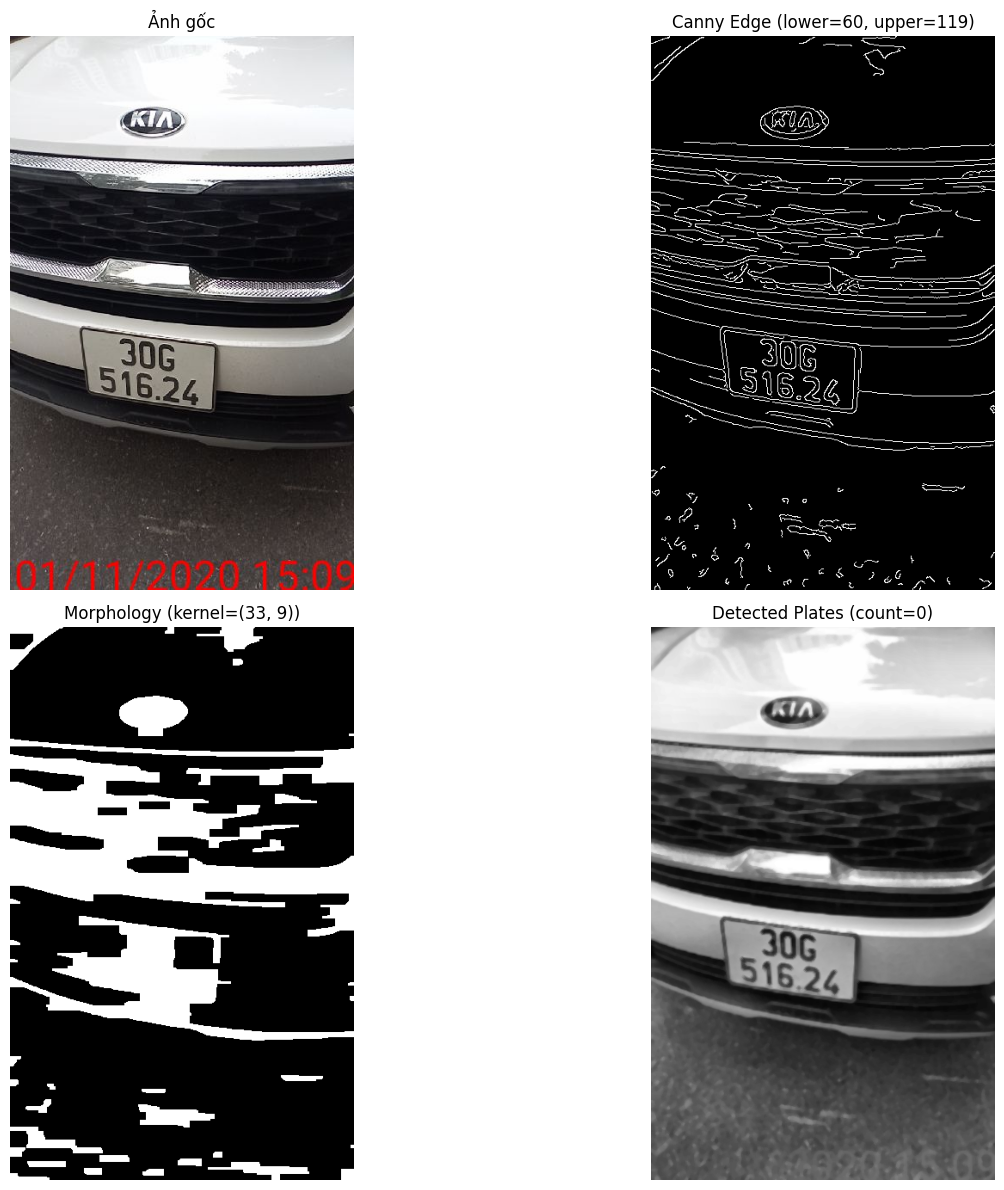

In [62]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """Tính tự động Canny thresholds dựa trên median pixel value."""
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3_fixed(image_preprocessed,
                                   sigma=0.33,
                                   area_ratio_range=(0.02, 0.20),  # ⬆️ Tăng max từ 0.15 → 0.20
                                   aspect_ratio_range=(0.8, 3.5),
                                   min_solidity=0.5,
                                   kernel_width_ratio=0.08,  # ⬇️ Giảm từ 0.1 → 0.08
                                   kernel_height_ratio=0.015, # ⬇️ Giảm từ 0.02 → 0.015
                                   debug=False):
    """
    Phát hiện biển số với Adaptive Parameters (tỷ lệ % diện tích ảnh).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: Tuple(min%, max%) - % diện tích ảnh
        aspect_ratio_range: Khoảng W/H của biển số
        min_solidity: Mức độ "đặc" của contour (0-1)
        kernel_width_ratio: % chiều rộng ảnh (nới lỏng hơn)
        kernel_height_ratio: % chiều cao ảnh (nới lỏng hơn)
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)] - bounding boxes
        debug_info: Dictionary chứa intermediate images & statistics
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    # ========== 1. ADAPTIVE AREA THRESHOLDS ==========
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image dimensions: {img_width}x{img_height}, area={img_area}")
        print(f"   Adaptive area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    # ========== 2. AUTO CANNY THRESHOLDS ==========
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Auto Canny Thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # ========== 3. CANNY EDGE DETECTION ==========
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # ========== 4. ADAPTIVE MORPHOLOGICAL OPERATIONS ==========
    # Tính kích thước kernel dựa trên kích thước ảnh (nới lỏng hơn v3)
    kernel_width = max(5, int(img_width * kernel_width_ratio))
    kernel_height = max(3, int(img_height * kernel_height_ratio))
    
    # Đảm bảo kernel có kích thước lẻ
    if kernel_width % 2 == 0:
        kernel_width += 1
    if kernel_height % 2 == 0:
        kernel_height += 1
    
    if debug:
        print(f"🔧 Adaptive kernel: close_kernel=({kernel_width}, {kernel_height})")
    
    # Close kernel: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Open kernel: loại bỏ nhiễu nhỏ (proportional to close kernel)
    kernel_open_w = max(3, kernel_width // 5)
    kernel_open_h = max(3, kernel_height // 5)
    if kernel_open_w % 2 == 0:
        kernel_open_w += 1
    if kernel_open_h % 2 == 0:
        kernel_open_h += 1
    
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_open_w, kernel_open_h))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # ========== 5. FIND CONTOURS ==========
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ========== 6. GEOMETRIC FILTERING ==========
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0, "margin": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # **Filter 1: Diện tích (adaptive)**
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # **Filter 2: Tỷ lệ khung hình (W/H)**
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # **Filter 3: Solidity (độ "đặc")**
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # **Filter 4: Khoảng cách từ cạnh ảnh (nới lỏng hơn)**
        margin = max(3, int(img_width * 0.03))  # ⬇️ Giảm từ 5% → 3%
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            rejected_stats["margin"] += 1
            continue
        
        # ✅ Passed all filters
        plates.append((x, y, w, h))
        
        if debug:
            print(f"  ✓ Plate found: Area={area:.0f}, AR={aspect_ratio:.2f}, Solidity={solidity:.2f}")
    
    # ========== DEBUG INFO ==========
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": contours,
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": (kernel_width, kernel_height),
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • Bị từ chối (margin): {rejected_stats['margin']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    
    return plates, debug_info

# ========== TEST ==========
detected_plates, debug_info = detect_license_plate_v3_fixed(
    process_images['clahe'],
    sigma=0.33,
    area_ratio_range=(0.02, 0.20),  # 2%-20% diện tích ảnh
    kernel_width_ratio=0.08,        # 8% chiều rộng (nhỏ hơn v3)
    kernel_height_ratio=0.015,      # 1.5% chiều cao (nhỏ hơn v3)
    min_solidity=0.5,
    debug=True
)

print(f"\n✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# ========== VISUALIZE ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny edges
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny Edge (lower={debug_info['canny_lower']}, upper={debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology result
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result with detected plates
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Phiên bản Final: v3_hybrid (Adaptive Area + Fixed Kernel)
---
Kết hợp ưu điểm của v2 và v3:
- Adaptive Area (% diện tích ảnh) để linh hoạt với ảnh khác kích thước
- Fixed Kernel (25x5) để bảo toàn cấu trúc biển số như v2
- Auto Canny để thích ứng ánh sáng
- Geometric Filters để lọc chính xác

📐 Image: 400x644, area=257600
   Area range: 5152-64400 (2.0%-25.0%)
📊 Canny: 60-119
🔧 Kernel: fixed (25,5)
  ✓ Area=12994, AR=1.86, Sol=0.92

📈 Summary: 67 contours → 1 plates
   Rejected - area:65 AR:1 solidity:0 margin:0

Found 1 plates
  Plate 1: pos=(55, 337), size=(190x102), ratio=1.86


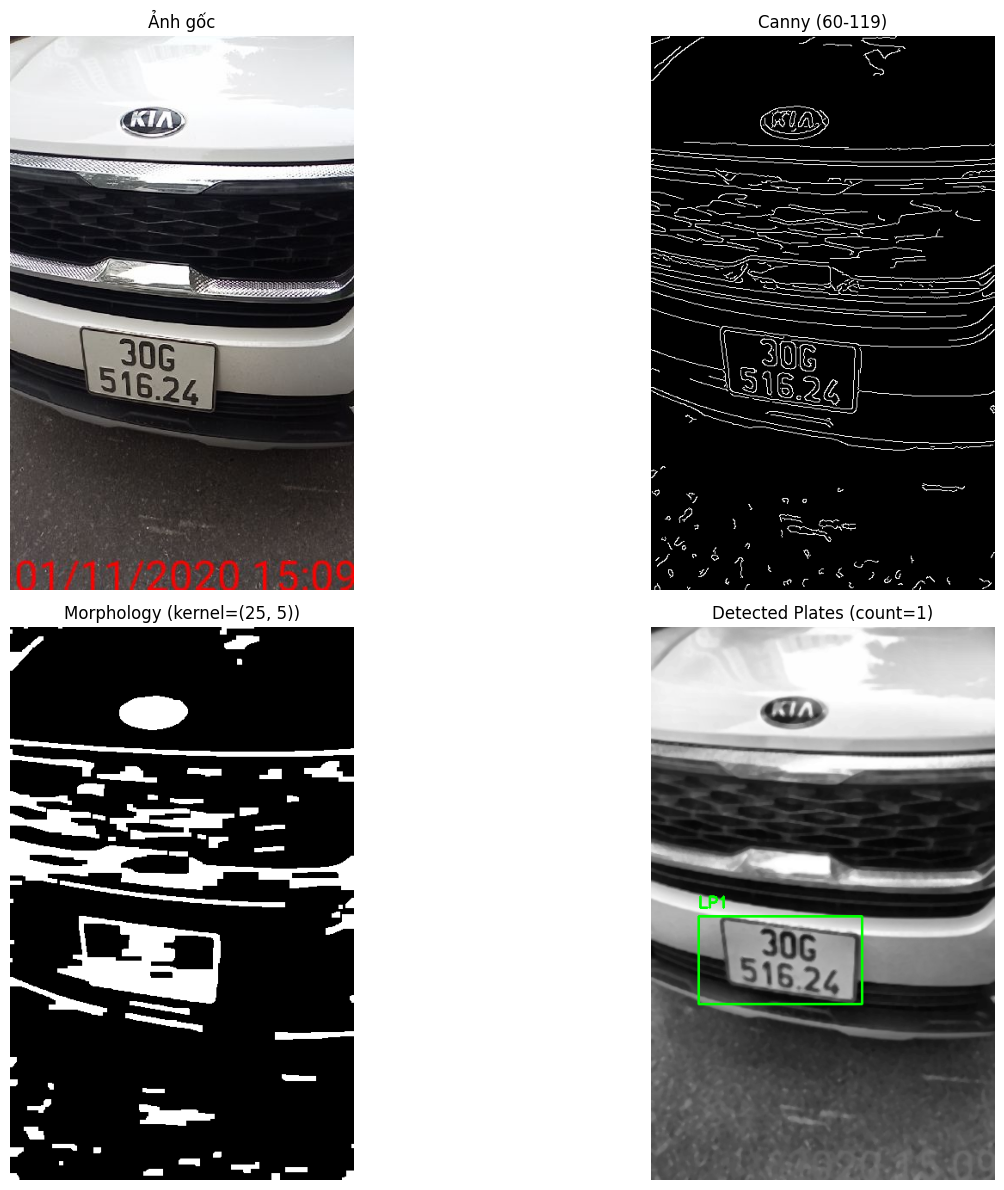

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """Tính tự động Canny thresholds dựa trên median pixel value."""
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3_hybrid(image_preprocessed,
                                    sigma=0.33,
                                    area_ratio_range=(0.02, 0.25),  # 2%-25% diện tích ảnh
                                    aspect_ratio_range=(0.8, 3.5),
                                    min_solidity=0.5,
                                    use_fixed_kernel=True,  # Dùng fixed kernel như v2
                                    debug=False):
    """
    Phát hiện biển số - Hybrid: Adaptive Area + Fixed Kernel (v2 proven).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: % diện tích ảnh (adaptive)
        aspect_ratio_range: Khoảng W/H
        min_solidity: Độ "đặc" tối thiểu
        use_fixed_kernel: True = dùng kernel v2 (25,5), False = adaptive
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)]
        debug_info: Dictionary với intermediate images & stats
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    # ========== 1. ADAPTIVE AREA THRESHOLDS ==========
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image: {img_width}x{img_height}, area={img_area}")
        print(f"   Area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    # ========== 2. AUTO CANNY ==========
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Canny: {lower_canny}-{upper_canny}")
    
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # ========== 3. MORPHOLOGY - FIXED KERNEL (v2 proven) ==========
    if use_fixed_kernel:
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))  # ✓ v2 kernel
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_info = "fixed (25,5)"
    else:
        # Fallback: adaptive kernel nhỏ hơn
        kernel_width = max(5, int(img_width * 0.06))  # 6% chiều rộng
        kernel_height = max(3, int(img_height * 0.01))  # 1% chiều cao
        if kernel_width % 2 == 0:
            kernel_width += 1
        if kernel_height % 2 == 0:
            kernel_height += 1
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_info = f"adaptive ({kernel_width},{kernel_height})"
    
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    if debug:
        print(f"🔧 Kernel: {kernel_info}")
    
    # ========== 4. FIND CONTOURS ==========
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ========== 5. GEOMETRIC FILTERING ==========
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0, "margin": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # Filter 1: Diện tích (adaptive)
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # Filter 2: Tỷ lệ W/H
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # Filter 3: Solidity
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # Filter 4: Margin (adaptive)
        margin = max(3, int(img_width * 0.03))
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            rejected_stats["margin"] += 1
            continue
        
        # ✅ Pass all filters
        plates.append((x, y, w, h))
        if debug:
            print(f"  ✓ Area={area:.0f}, AR={aspect_ratio:.2f}, Sol={solidity:.2f}")
    
    # ========== DEBUG INFO ==========
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": contours,
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": (25, 5) if use_fixed_kernel else (kernel_width, kernel_height),
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Summary: {len(contours)} contours → {len(plates)} plates")
        print(f"   Rejected - area:{rejected_stats['area']} AR:{rejected_stats['aspect_ratio']} "
              f"solidity:{rejected_stats['solidity']} margin:{rejected_stats['margin']}")
    
    return plates, debug_info

# ========== TEST ==========
detected_plates, debug_info = detect_license_plate_v3_hybrid(
    process_images['clahe'],
    area_ratio_range=(0.02, 0.25),  # 2%-25% diện tích ảnh
    use_fixed_kernel=True,          # Dùng kernel v2
    debug=True
)

print(f"\nFound {len(detected_plates)} plates")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: pos=({x}, {y}), size=({w}x{h}), ratio={w/h:.2f}")

# ========== VISUALIZE ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny ({debug_info['canny_lower']}-{debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Debug: So sánh kernel sizes

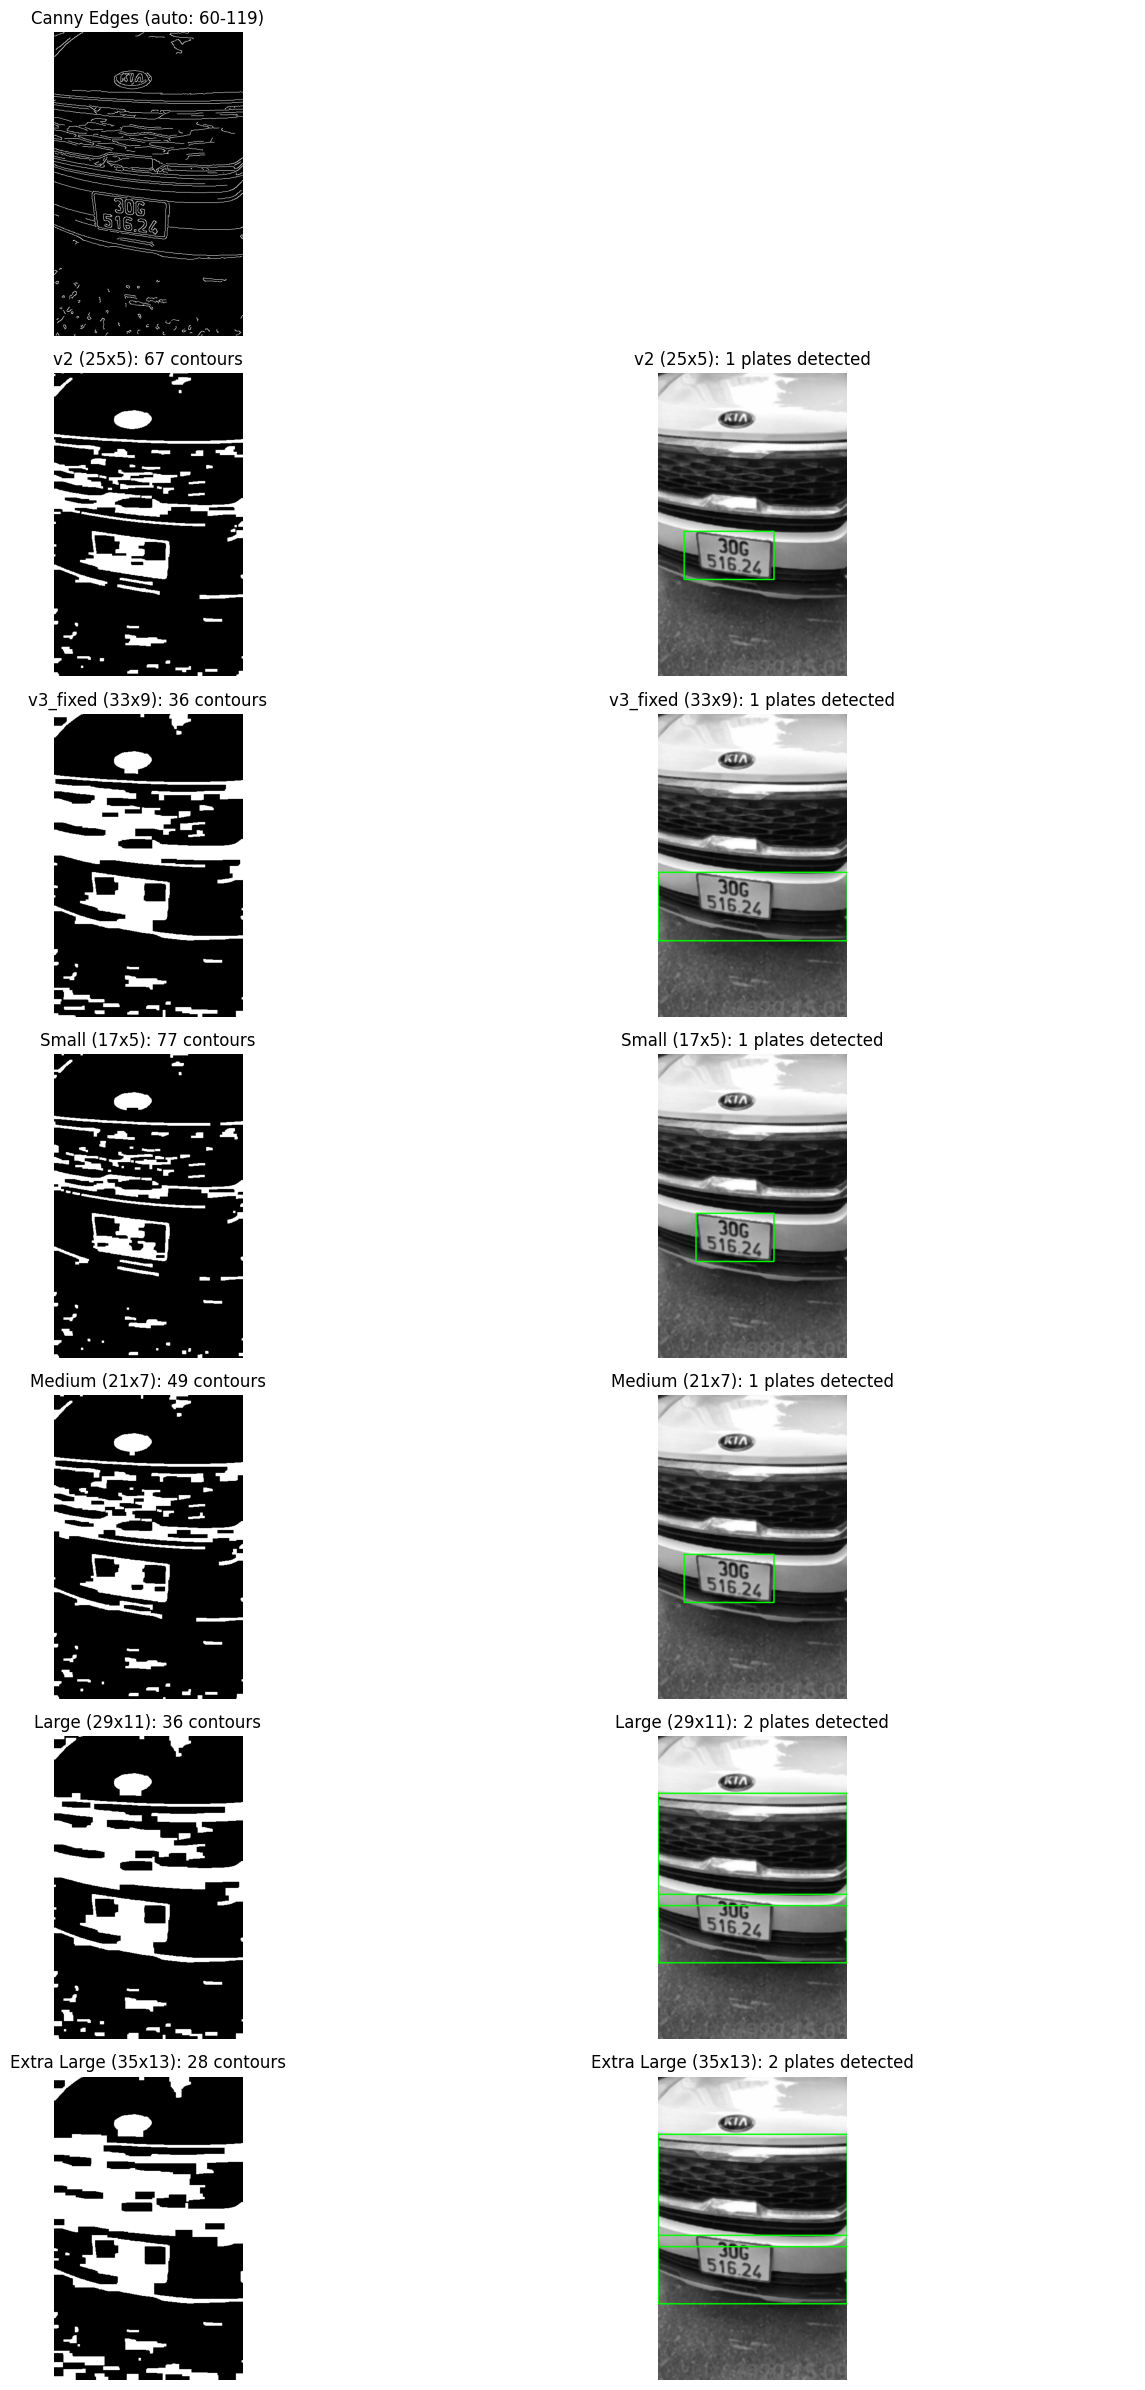

✅ So sánh xong! Kernel nào có bounding box xanh = thành công


In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Test nhiều kernel sizes để tìm tối ưu
img_preprocessed = process_images['clahe']
img_height, img_width = img_preprocessed.shape

lower_canny, upper_canny = auto_canny(img_preprocessed, sigma=0.33)
edges = cv2.Canny(img_preprocessed, lower_canny, upper_canny)

kernel_tests = [
    ("v2 (25x5)", (25, 5)),
    ("v3_fixed (33x9)", (33, 9)),
    ("Small (17x5)", (17, 5)),
    ("Medium (21x7)", (21, 7)),
    ("Large (29x11)", (29, 11)),
    ("Extra Large (35x13)", (35, 13))
]

fig, axes = plt.subplots(len(kernel_tests) + 1, 2, figsize=(14, 4 * len(kernel_tests)))

# Row 0: Original Canny
axes[0, 0].imshow(edges, cmap='gray')
axes[0, 0].set_title(f'Canny Edges (auto: {lower_canny}-{upper_canny})')
axes[0, 0].axis('off')
axes[0, 1].axis('off')

# Test each kernel
for idx, (name, (kw, kh)) in enumerate(kernel_tests):
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Morphology result
    axes[idx + 1, 0].imshow(morph, cmap='gray')
    axes[idx + 1, 0].set_title(f'{name}: {len(contours)} contours')
    axes[idx + 1, 0].axis('off')
    
    # Draw contours on original
    result = cv2.cvtColor(img_preprocessed, cv2.COLOR_GRAY2BGR)
    
    # Apply filters
    min_area = int(img_height * img_width * 0.02)
    max_area = int(img_height * img_width * 0.25)
    plates_found = 0
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        # Check filters
        if (min_area <= area <= max_area and 
            0.8 <= aspect_ratio <= 3.5 and 
            solidity >= 0.5):
            cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
            plates_found += 1
    
    axes[idx + 1, 1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[idx + 1, 1].set_title(f'{name}: {plates_found} plates detected')
    axes[idx + 1, 1].axis('off')

plt.tight_layout()
plt.show()

print("✅ So sánh xong! Kernel nào có bounding box xanh = thành công")